# EDA — PNCP / Compras.gov.br 2025

**Fonte única:** `data/comprasGOV-anual-VW_FT_PNCP_COMPRA-2025.xls` (CSV UTF-8, extensão `.xls`)

**Recorte:** `orgao_entidade_esfera_id == "D"` (distrital / **GDF**) e `ano_compra_pncp == 2025` (~2,6 mil compras; exclui órgãos federais sediados no DF).

**Label proxy:** `orgao_entidade_razao_social` → 6 macroáreas (`src/preprocess/labels.py`).

### Célula 1 — Configuração do ambiente e carregamento

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display


def br_num(n: int | float) -> str:
    return f"{int(n):,}".replace(",", ".")


def br_money(v: float) -> str:
    return "R$ " + f"{v:,.0f}".replace(",", ".")


def show_table(titulo, colunas, linhas, alinhamentos=None):
    if alinhamentos is None:
        alinhamentos = ["left"] + ["right"] * (len(colunas) - 1)
    estilo_th = (
        "padding:8px 12px;border:1px solid #475569;"
        "background:#1e40af;color:#fff;font-weight:600;"
    )
    estilo_td = "padding:8px 12px;border:1px solid #cbd5e1;background:#fff;color:#111827;"
    corpo = ""
    for row in linhas:
        tds = "".join(
            f"<td style='{estilo_td}text-align:{a};'>{v}</td>"
            for v, a in zip(row, alinhamentos)
        )
        corpo += f"<tr>{tds}</tr>"
    ths = "".join(
        f"<th style='{estilo_th}text-align:{a};'>{c}</th>"
        for c, a in zip(colunas, alinhamentos)
    )
    html = (
        f"<div style='margin:14px 0;font-family:Segoe UI,sans-serif;'>"
        f"<div style='font-size:14px;font-weight:bold;margin-bottom:8px;'>{titulo}</div>"
        f"<table style='border-collapse:collapse;font-size:13px;'>"
        f"<thead><tr>{ths}</tr></thead><tbody>{corpo}</tbody></table></div>"
    )
    display(HTML(html))


ROOT = Path.cwd()
if (ROOT / "src").exists():
    pass
elif (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from src.preprocess.labels import AREAS, area_for_orgao, normalize

PNCP_PATH = ROOT / "data" / "comprasGOV-anual-VW_FT_PNCP_COMPRA-2025.xls"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Carregando {PNCP_PATH.name} ...")
df_raw = pd.read_csv(PNCP_PATH, encoding="utf-8", low_memory=False)
df = df_raw[
    (df_raw["orgao_entidade_esfera_id"] == "D")
    & (df_raw["ano_compra_pncp"] == 2025)
].copy()
df["area"] = df["orgao_entidade_razao_social"].map(area_for_orgao)
df["objeto"] = df["objeto_compra"].fillna("")
df["texto"] = (
    df["orgao_entidade_razao_social"].fillna("")
    + " "
    + df["unidade_orgao_nome_unidade"].fillna("")
    + " "
    + df["objeto_compra"].fillna("")
    + " "
    + df["informacao_complementar"].fillna("")
).str.strip()
records = df.to_dict("records")
print(f"OK: {len(records):,} compras (GDF esfera D / 2025)".replace(",", "."))

cols_chave = [
    ("cod_compra", "ID interno PNCP"),
    ("numero_controle_PNCP", "Identificador único"),
    ("modalidade_nome", "Modalidade (pregão, dispensa...)"),
    ("modo_disputa_nome_pncp", "Modo de disputa"),
    ("orgao_entidade_razao_social", "Órgão comprador (→ label)"),
    ("unidade_orgao_uf_sigla", "UF"),
    ("objeto_compra", "Descrição do objeto"),
    ("valor_total_homologado", "Valor homologado (R$)"),
    ("area", "Macroárea derivada do órgão"),
]

show_table(
    "TABELA 1 — Visão geral PNCP 2025",
    ["Métrica", "Valor"],
    [
        ["Arquivo", PNCP_PATH.name],
        ["Total de compras", br_num(len(records))],
        ["Colunas no arquivo", br_num(len(df.columns))],
        ["UFs distintas", br_num(df["unidade_orgao_uf_sigla"].nunique())],
        ["Label (macroárea)", "area (derivado de orgao_entidade_razao_social)"],
    ],
)

show_table(
    "TABELA 1b — Colunas principais",
    ["#", "Campo", "Descrição"],
    [[str(i), c, d] for i, (c, d) in enumerate(cols_chave, 1)],
    ["right", "left", "left"],
)


Carregando comprasGOV-anual-VW_FT_PNCP_COMPRA-2025.xls ...


OK: 322.098 compras


Métrica,Valor
Arquivo,comprasGOV-anual-VW_FT_PNCP_COMPRA-2025.xls
Total de compras,322.098
Colunas no arquivo,62
UFs distintas,27
Label (macroárea),area (derivado de orgao_entidade_razao_social)


#,Campo,Descrição
1,cod_compra,ID interno PNCP
2,numero_controle_PNCP,Identificador único
3,modalidade_nome,"Modalidade (pregão, dispensa...)"
4,modo_disputa_nome_pncp,Modo de disputa
5,orgao_entidade_razao_social,Órgão comprador (→ label)
6,unidade_orgao_uf_sigla,UF
7,objeto_compra,Descrição do objeto
8,valor_total_homologado,Valor homologado (R$)
9,area,Macroárea derivada do órgão


#### Resultado da Célula 1

Carregamos **todas** as compras do arquivo PNCP 2025. O label `area` vem do **nome do órgão**, mesma regra de palavras-chave usada no projeto de classificação.

## 1. Distribuição das macroáreas (label)

Label derivado de `orgao_entidade_razao_social` — ver `src/preprocess/labels.py`.

### Célula 2 — Gráfico de distribuição das macroáreas

Macroárea,N compras,% do total
Saude,27.152,8.4%
Saneamento,768,0.2%
Seguranca,18.687,5.8%
Educacao,16.230,5.0%
Infraestrutura/Obras,2.234,0.7%
Administracao/Outros,257.027,79.8%


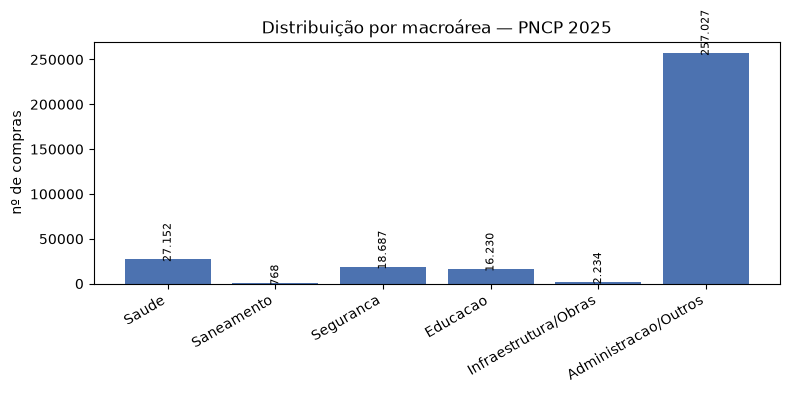

In [2]:
area_counts = Counter(r["area"] for r in records)
ordered = [(a, area_counts.get(a, 0)) for a in AREAS]
total = len(records)

show_table(
    "TABELA 2 — Distribuição por macroárea (label)",
    ["Macroárea", "N compras", "% do total"],
    [[a, br_num(n), f"{100 * n / total:.1f}%"] for a, n in ordered],
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([a for a, _ in ordered], [n for _, n in ordered], color="#4C72B0")
ax.set_ylabel("nº de compras")
ax.set_title("Distribuição por macroárea — PNCP 2025")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for i, (_, n) in enumerate(ordered):
    if n > 0:
        ax.text(i, n, br_num(n), ha="center", fontsize=8, rotation=90)
fig.tight_layout()
fig.savefig(FIGURES / "eda_pncp_areas.png", dpi=120)
plt.show()


#### Resultado da Célula 2

A classe **Administração/Outros** domina (fallback quando o órgão não casa com keyword). Corpus nacional e muito maior que um recorte DF — desbalanceamento é esperado.

## 2. Modalidade e modo de disputa

### Célula 3 — Contagem de modalidade e modo de disputa

In [3]:
rotulos = {
    "modalidade_nome": "Modalidade de licitação",
    "modo_disputa_nome_pncp": "Modo de disputa",
}
tabela_num = 3
for campo, rotulo in rotulos.items():
    contagem = Counter(r.get(campo, "") or "(vazio)" for r in records).most_common(8)
    tot = sum(n for _, n in contagem)
    show_table(
        f"TABELA {tabela_num} — {rotulo}",
        ["Valor", "N", "%"],
        [[v, br_num(n), f"{100 * n / tot:.1f}%"] for v, n in contagem],
        ["left", "right", "right"],
    )
    tabela_num += 1


Valor,N,%
Dispensa,129.951,40.3%
Pregão - Eletrônico,114.698,35.6%
Inexigibilidade,65.350,20.3%
Concorrência - Eletrônica,8.550,2.7%
Credenciamento,2.525,0.8%
Concorrência - Presencial,747,0.2%
Pregão - Presencial,221,0.1%
Concurso,56,0.0%


Valor,N,%
Não se aplica,123.634,38.4%
Aberto,76.483,23.7%
Dispensa Com Disputa,74.194,23.0%
Aberto-Fechado,45.998,14.3%
Fechado-Aberto,956,0.3%
Fechado,833,0.3%


#### Resultado da Célula 3

**Dispensa** e **Pregão Eletrônico** concentram a maior parte das compras no PNCP nacional.

## 3. Tamanho dos textos (`objeto_compra` e `texto` completo)

### Célula 4 — Histograma do tamanho dos textos em palavras

Métrica,Valor
Mínimo,0 palavras
Mediana,23 palavras
Máximo,378 palavras
Compras com > 512 palavras,0
% acima de 512 palavras,0.0%
Mediana texto completo,44 palavras


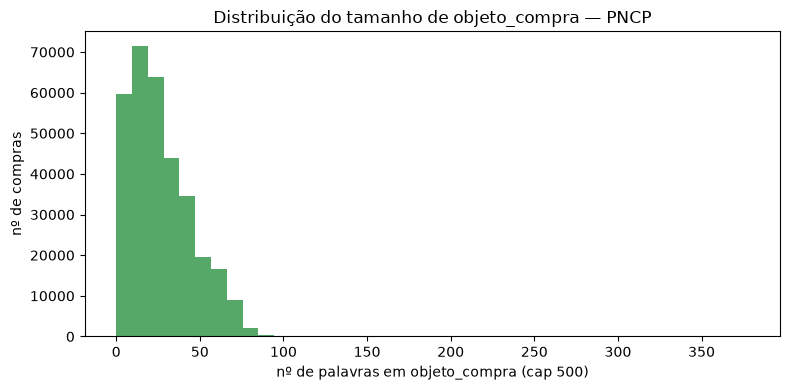

In [4]:
word_obj = [len((r.get("objeto") or "").split()) for r in records]
word_texto = [len((r.get("texto") or "").split()) for r in records]
n = len(word_obj)
mediana = sorted(word_obj)[n // 2] if n else 0
acima_512 = sum(1 for w in word_obj if w > 512)

show_table(
    "TABELA 5 — Tamanho em palavras (objeto_compra)",
    ["Métrica", "Valor"],
    [
        ["Mínimo", br_num(min(word_obj) if word_obj else 0) + " palavras"],
        ["Mediana", br_num(mediana) + " palavras"],
        ["Máximo", br_num(max(word_obj) if word_obj else 0) + " palavras"],
        ["Compras com > 512 palavras", br_num(acima_512)],
        ["% acima de 512 palavras", f"{100 * acima_512 / n:.1f}%" if n else "0,0%"],
        ["Mediana texto completo", br_num(sorted(word_texto)[n // 2] if n else 0) + " palavras"],
    ],
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([min(w, 500) for w in word_obj], bins=40, color="#55A868")
ax.set_xlabel("nº de palavras em objeto_compra (cap 500)")
ax.set_ylabel("nº de compras")
ax.set_title("Distribuição do tamanho de objeto_compra — PNCP")
fig.tight_layout()
fig.savefig(FIGURES / "eda_pncp_tamanho_texto.png", dpi=120)
plt.show()


#### Resultado da Célula 4

No PNCP, `objeto_compra` é **curto** (mediana ~25 palavras) — metadado resumido, não o edital HTML completo. Poucas compras passam de 512 palavras.

## 4. Valor homologado por macroárea

### Célula 5 — Tabela e gráfico de valor homologado por macroárea

Macroárea,N c/ valor,Soma,Mediana
Saude,20.791,R$ 85.255.580.936,R$ 44.655
Saneamento,601,R$ 1.523.303.511,R$ 198.467
Seguranca,16.481,R$ 241.277.635.256,R$ 19.253
Educacao,14.477,R$ 105.364.433.747,R$ 17.500
Infraestrutura/Obras,1.730,R$ 27.439.381.200,R$ 19.597
Administracao/Outros,213.955,R$ 740.471.457.293,R$ 23.473


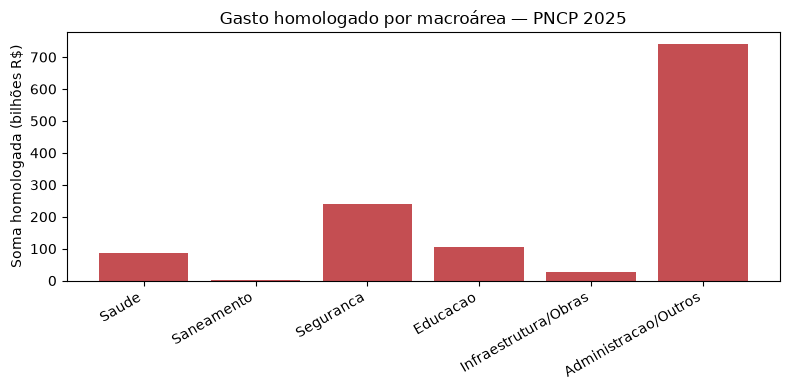

In [5]:
por_area = {a: [] for a in AREAS}
for r in records:
    val = r.get("valor_total_homologado")
    if pd.notna(val) and float(val) > 0:
        por_area[r["area"]].append(float(val))

linhas_valor = []
for a in AREAS:
    vals = sorted(por_area[a])
    if vals:
        linhas_valor.append([a, br_num(len(vals)), br_money(sum(vals)), br_money(vals[len(vals) // 2])])
    else:
        linhas_valor.append([a, "0", "—", "—"])

show_table(
    "TABELA 6 — Valor homologado por macroárea",
    ["Macroárea", "N c/ valor", "Soma", "Mediana"],
    linhas_valor,
    ["left", "right", "right", "right"],
)

somas = [sum(por_area[a]) for a in AREAS]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(AREAS, [s / 1e9 for s in somas], color="#C44E52")
ax.set_ylabel("Soma homologada (bilhões R$)")
ax.set_title("Gasto homologado por macroárea — PNCP 2025")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIGURES / "eda_pncp_valor_area.png", dpi=120)
plt.show()


#### Resultado da Célula 5

Saúde e Administração/Outros concentram volume financeiro. Mediana por área ajuda a ver o gasto "típico" sem outliers.

## 5. Vazamento de label por palavras-chave

### Célula 6 — Análise de vazamento de label

In [6]:
from src.preprocess.labels import AREA_KEYWORDS
from src.preprocess.clean_objeto import limpar_objeto

kw_by_area = dict(AREA_KEYWORDS)


def contem_keyword(texto: str, area: str) -> bool:
    kws = kw_by_area.get(area)
    if not kws:
        return False
    alvo = normalize(texto)
    return any(kw in alvo for kw in kws)


for r in records:
    r["objeto_limpo"] = limpar_objeto(
        r.get("objeto") or "",
        orgao=r.get("orgao_entidade_razao_social"),
    )

com_kw = [r for r in records if r["area"] in kw_by_area]
vaz_texto = sum(contem_keyword(r.get("texto", ""), r["area"]) for r in com_kw)
vaz_obj = sum(contem_keyword(r.get("objeto", ""), r["area"]) for r in com_kw)
vaz_limpo = sum(contem_keyword(r.get("objeto_limpo", ""), r["area"]) for r in com_kw)
base = len(com_kw)

if base:
    show_table(
        "TABELA 7 — Vazamento de label (palavra-chave da área no texto)",
        ["Campo analisado", "Com vazamento", "Total", "Taxa"],
        [
            ["texto (órgão + objeto + complemento)", br_num(vaz_texto), br_num(base), f"{100 * vaz_texto / base:.1f}%"],
            ["objeto_compra (só objeto)", br_num(vaz_obj), br_num(base), f"{100 * vaz_obj / base:.1f}%"],
            ["objeto_limpo (sem boilerplate)", br_num(vaz_limpo), br_num(base), f"{100 * vaz_limpo / base:.1f}%"],
        ],
        ["left", "right", "right", "right"],
    )

print(f"Compras analisadas (áreas com keyword): {br_num(base)}")
print(f"Compras em Administração/Outros (excluídas da Tabela 7): {br_num(len(records) - base)}")


Campo analisado,Com vazamento,Total,Taxa
texto (órgão + objeto + complemento),65.071,65.071,100.0%
objeto_compra (só objeto),11.318,65.071,17.4%
objeto_limpo (sem boilerplate),11.136,65.071,17.1%


Compras analisadas (áreas com keyword): 65.071
Compras em Administração/Outros (excluídas da Tabela 7): 257.027


#### Resultado da Célula 6 — Tabela 7

Compara três entradas de texto:
- **texto** — concatena órgão + unidade + objeto + complemento (análogo ao HTML completo)
- **objeto_compra** — só a descrição da compra (entrada honesta para PLN)
- **objeto_limpo** — objeto após `limpar_objeto()`

Compras em `Administracao/Outros` ficam **fora** da Tabela 7 (sem keyword própria). Quanto menor a taxa em `objeto_compra`, menos o modelo pode "colar" no label pelo órgão.

## 6. Vazamento residual — nome do órgão em `objeto_compra`

### Célula 7 — Auditoria complementar (Tabela 8)

In [7]:
def orgao_aparece_no_texto(orgao: str, texto: str) -> bool:
    org = normalize(orgao or "")
    if len(org) < 8:
        return False
    return org in normalize(texto or "")


residual = [
    r for r in records
    if orgao_aparece_no_texto(r.get("orgao_entidade_razao_social", ""), r.get("objeto", ""))
]
n_res, n_tot = len(residual), len(records)
taxa = n_res / n_tot if n_tot else 0

show_table(
    "TABELA 8 — Vazamento residual (nome do órgão em objeto_compra)",
    ["Métrica", "Valor"],
    [
        ["Compras com órgão no objeto", f"{br_num(n_res)} / {br_num(n_tot)}"],
        ["Taxa", f"{taxa:.1%}"],
        ["Entrada recomendada para PLN", "objeto_compra (documentar taxa)"],
    ],
    ["left", "left"],
)

if residual:
    show_table(
        "Exemplos de vazamento residual (até 8)",
        ["Controle PNCP", "Órgão", "Trecho objeto_compra"],
        [
            [
                (r.get("numero_controle_PNCP") or "?")[:28],
                (r.get("orgao_entidade_razao_social") or "")[:40],
                ((r.get("objeto") or "")[:80] + "…"),
            ]
            for r in residual[:8]
        ],
        ["left", "left", "left"],
    )


Métrica,Valor
Compras com órgão no objeto,22.290 / 322.098
Taxa,6.9%
Entrada recomendada para PLN,objeto_compra (documentar taxa)


Controle PNCP,Órgão,Trecho objeto_compra
46395000000139-1-000086/2025,MUNICIPIO DE SAO PAULO,"Aquisição de bandeiras Brasil, Estado de São Paulo e Município de São Paulo e ba…"
46395000000139-1-000009/2025,MUNICIPIO DE SAO PAULO,Contratação para execução de obras civis de reforma e adequação de ambientes por…
95719373000123-1-000154/2025,MUNICIPIO DE MERCEDES,"Contratação de empresa, através da política pública denominada “Compra Mercedes”…"
95719373000123-1-000156/2025,MUNICIPIO DE MERCEDES,LICITAÇÃO EXCLUSIVA PARA A PARTICIPAÇÃO DE MICROEMPRESAS E EMPRESAS DE PEQUENO P…
95719373000123-1-000163/2025,MUNICIPIO DE MERCEDES,"Contratação de empresa especializada em engenharia elétrica cadastrada na Copel,…"
95719373000123-1-000141/2025,MUNICIPIO DE MERCEDES,Contratação de empresa para realização de serviços de ampliação da Unidade Básic…
95719373000123-1-000079/2025,MUNICIPIO DE MERCEDES,LICITAÇÃO EXCLUSIVA PARA A PARTICIPAÇÃO DE MICROEMPRESAS E EMPRESAS DE PEQUENO P…
95719373000123-1-000078/2025,MUNICIPIO DE MERCEDES,LICITAÇÃO EXCLUSIVA PARA A PARTICIPAÇÃO DE MICROEMPRESAS E EMPRESAS DE PEQUENO P…


#### Resultado da Célula 7

Registros em que o **nome do órgão** ainda aparece em `objeto_compra`. Documentar a taxa é parte do rigor metodológico antes de treinar classificadores sobre PNCP.

### Célula — 9 setores, excluídas e vazamento lexical

Análise do corpus PNCP DF/2025 (`pncp_corpus_df2025.jsonl`): compras **com** keyword setorial no objeto vs **sem keyword** (excluídas do `pncp9`), classe **Indeterminado** (10ª classe) e percentual de vazamento.

Relatório completo: `reports/benchmark_pncp_casos_dificeis.json` (`python scripts/run_benchmark_pncp_dificeis.py`).

In [9]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path("..").resolve()
report_path = ROOT / "reports" / "benchmark_pncp_casos_dificeis.json"
if not report_path.exists():
    import subprocess
    subprocess.run(["python", "scripts/run_benchmark_pncp_dificeis.py"], cwd=ROOT, check=True)

report = json.loads(report_path.read_text(encoding="utf-8"))

rows = []
for name, info in report["cohorts"].items():
    rows.append({"Coorte": name, "N": info["n"], "% corpus": info["pct"]})
df_cohort = pd.DataFrame(rows)

print("Coortes (keyword no objeto_compra)")
display(df_cohort)

print(f"\nVazamento oraculo (label=keyword, entrada=objeto_html_limpo): {report['leakage']['oracle_match_limpo_pct']}%")
print(f"Sem vazamento: {report['leakage']['sem_vazamento_pct']}%")

print("\nEscondidas (~853): macroárea do órgão, objeto sem keyword")
display(pd.Series(report["escondidas_por_macroarea_orgao"], name="N").to_frame())

ev = report["eval_org_logreg_escondidas"]
if ev.get("status") == "ok":
    m = ev["metrics_test_escondidas"]
    print(f"\nLogReg (label órgão) nas escondidas: F1 macro={m['f1_macro']:.3f}, acc={m['accuracy']:.3f}")

det = report["eval_detecao_sinal_binario"]
print(f"Detecção binária 'tem keyword?': acc={det['test_accuracy']:.3f}, F1 positivo={det['test_f1_positivo']:.3f}")

print("\n10 classes (9 setores + Indeterminado):")
display(pd.Series(report["distribuicao_10_classes"], name="N").to_frame())

Coortes (keyword no objeto_compra)


,Coorte,N,% corpus
0,com_keyword,10311,51.7
1,sem_keyword_admin,8780,44.0
2,sem_keyword_macroarea_nomeada,853,4.3



Vazamento oraculo (label=keyword, entrada=objeto_html_limpo): 97.0%
Sem vazamento: 3.0%

Escondidas (~853): macroárea do órgão, objeto sem keyword


,N
Seguranca,311
Saude,279
Infraestrutura/Obras,157
Educacao,57
Saneamento,49



LogReg (label órgão) nas escondidas: F1 macro=0.653, acc=0.705
Detecção binária 'tem keyword?': acc=0.917, F1 positivo=0.916

10 classes (9 setores + Indeterminado):


,N
Indeterminado,9633
Saude,3070
TI/Administracao,1844
Infraestrutura/Obras,1366
Educacao,1101
Cultura,1098
Seguranca,869
Transporte,492
MeioAmbiente,272
Saneamento,199
